4000 4000


/home/krasa-35/ws/Masters/code/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/krasa-35/ws/Masters/code/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/krasa-35/ws/Masters/code/main/optimal/RobotMujocoModel.py:169: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Global FF coverage: {g_rms_ff/g_rms_tot*100:.1f}%   FB correction: {g_rms_fb/g_rms_tot*100:.1f}%")
/home/krasa-35/ws/Masters/code/main/optimal/RobotMujocoModel.py:196: RuntimeWarning: divide by zero encountered in scalar divide
  stats_text = f"Global FF coverage: {g_rms_ff/g_rms_tot*100:.1f}%\n"
/home/krasa-35/ws/Masters/code/main/optimal/RobotMujocoModel.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  stats_text += f"FB correction: {g_rms_fb/g_rms_tot*100:.1f}%\n"


Joint     Corr FF↔tot  RMS FF %  RMS FB %    MAE FB
-------------------------------------------------------
  1               nan    257.5%    257.5%    2.0101
  2               nan   6583.2%   6583.2%   58.6401
  3               nan   3578.4%   3578.4%   34.8586
  4               nan    267.2%    267.2%    2.4339
  5               nan     25.6%     25.6%    0.2027
  6               nan      0.2%      0.2%    0.0013
Global FF coverage: inf%   FB correction: inf%
Global correlation FF↔tot: nan


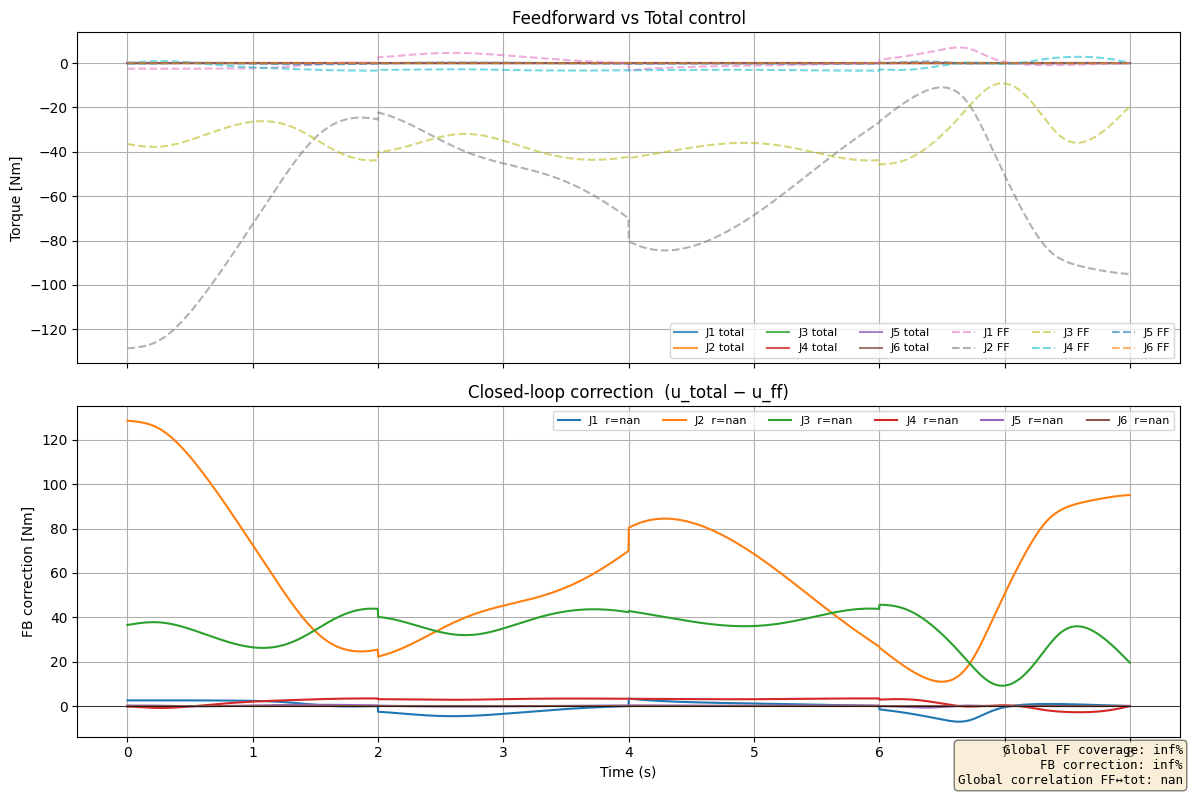

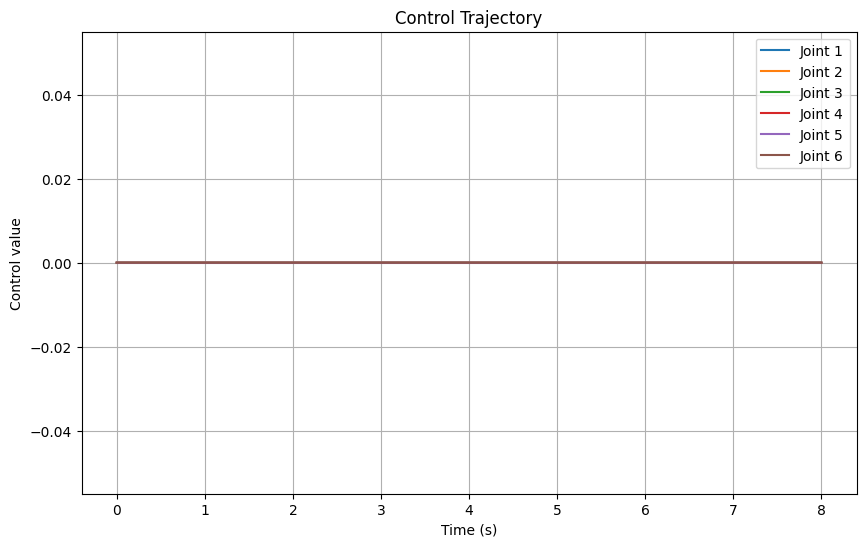

KeyboardInterrupt: 

In [1]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10, UR10_sandbox
from optimal.metrics import thermal_energy, mechanical_work, peak_power
import numpy as np
import crocoddyl

type = UR10_sandbox
kp = [1414.94,1693.23,1202.19,7.92,34.51,1.24]
kd = [204.882,113.588,148.053,0.687,3.741,0.178]
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]
controller = RobotController(robot_pin_model)
xs, us = [], []
v_start = np.zeros(len(robot_pin_model.v_indices))
for i in range(len(path) - 1):
    start = np.concatenate([path[i], v_start])
    target = np.concatenate([path[i+1], np.zeros(len(robot_pin_model.v_indices))])
    t_xs, t_us = controller.compute_control(x_start=start, 
                                        x_goal=target, 
                                        T=1000, DT=DT, kp=kp, kd=kd, acc_weight=1e1,
                                        ctrl_weight=1e3,
                                        alpha=0.9, interpolation="quintic",
                                        option="crocoddyl_advanced", solver=crocoddyl.SolverBoxFDDP)
    xs.extend(t_xs)
    us.extend(t_us)
    v_start = xs[-1][len(robot_pin_model.q_indices):]

print(len(xs), len(us))
xs_real, us_real = robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
# xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.closed_loop_kp, kd=type.closed_loop_kd, dt=DT, hold=False, plot=True)
# xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
# xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=type.kp, kd=type.kd)
# xs_real, us_real = robot_mj_model.simulate_control(us=us)
# robot_mj_model.plot_controls(us, dt=DT)
robot_mj_model.plot_feedback_part(us_real, us, dt=DT)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)

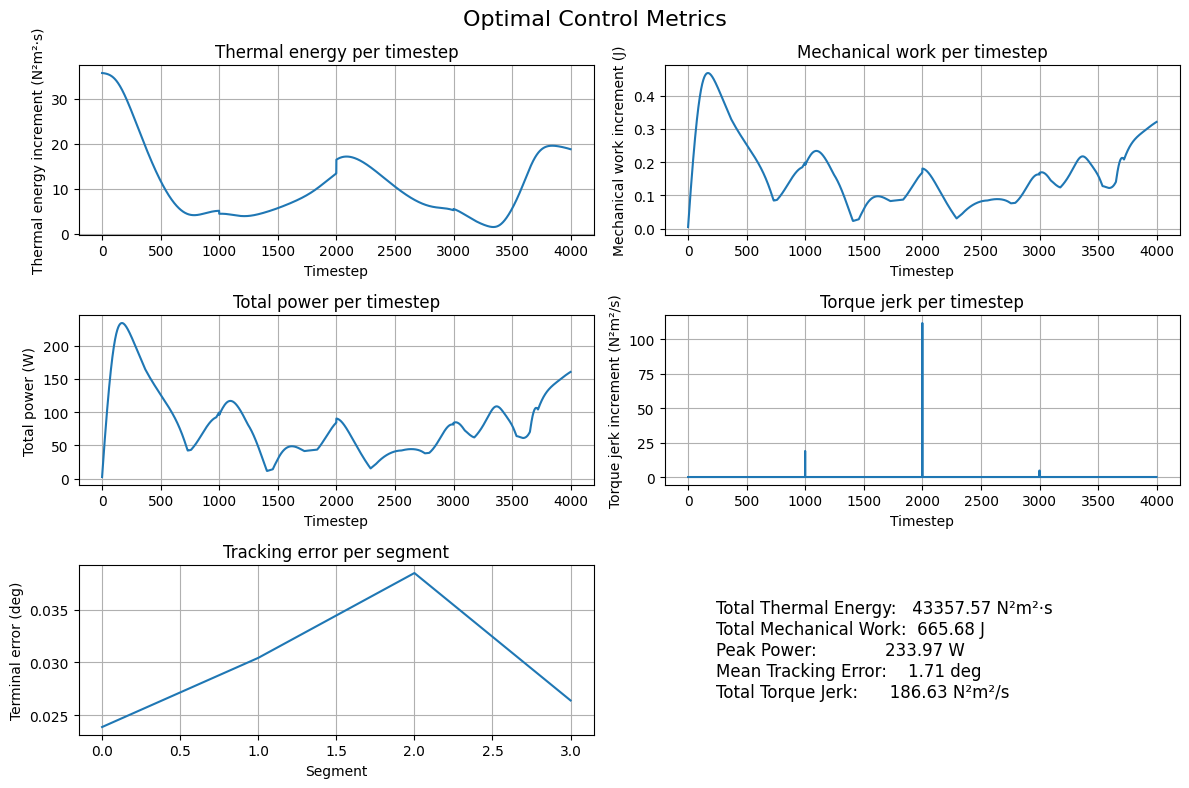

52864.2981702421

In [7]:
from optimal.metrics import plot_metrics, unified_cost

plot_metrics(us, xs, DT, path[1:], [1000]*(len(path)-1))
unified_cost(us, xs, DT, path[1:], [1000]*(len(path)-1))


Joint     Corr FF↔tot  RMS FF %  RMS FB %    MAE FB
-------------------------------------------------------
  1            0.9999     99.5%      1.3%    0.0627
  2            1.0000    100.0%      0.2%    0.1147
  3            1.0000    100.0%      0.1%    0.0251
  4            1.0000    100.0%      0.2%    0.0050
  5            0.9999    100.6%      1.3%    0.0028
  6            0.6585     45.7%     82.8%    0.0018
Global FF coverage: 100.0%   FB correction: 0.3%
Global correlation FF↔tot: 1.0000


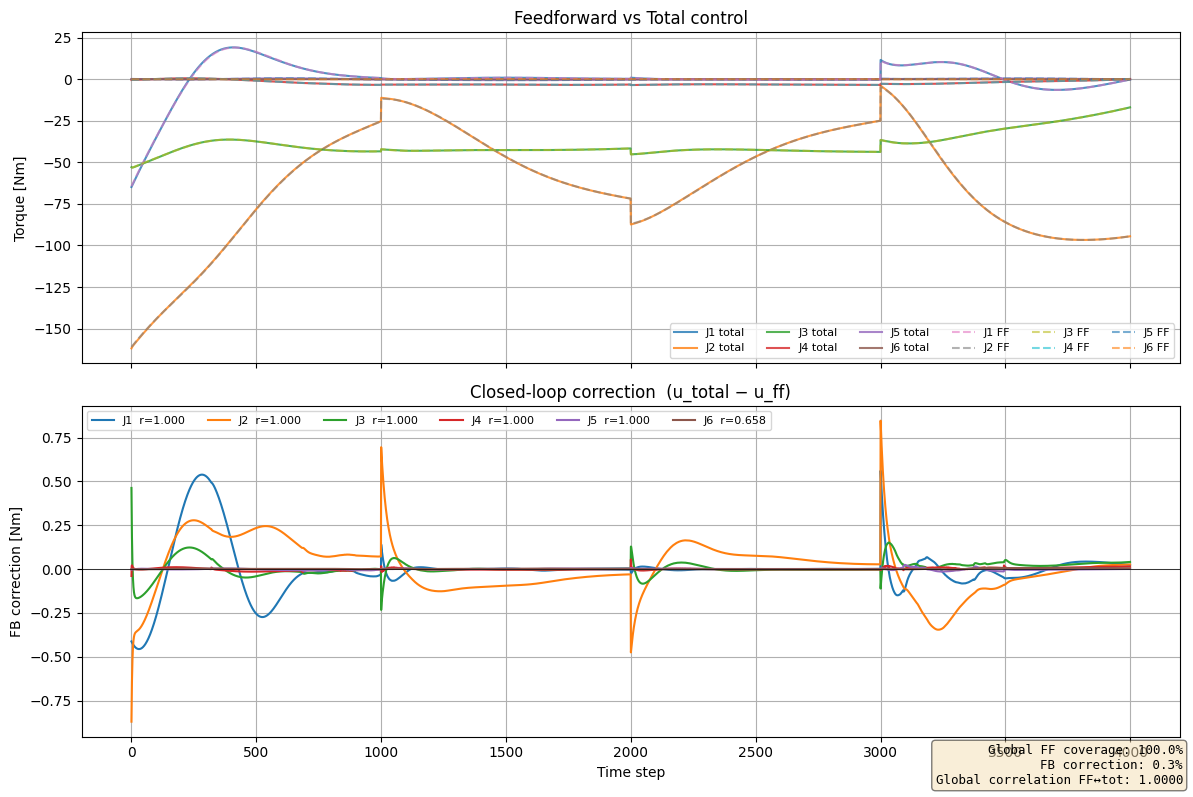

In [14]:
robot_mj_model.reset()
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False, plot=True)
